In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
for  dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [48]:
df = pd.read_csv("/content/Employee 1000x.csv")
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor


In [50]:
df.columns

Index(['Index', 'First Name', 'Last Name', 'Sex', 'Email', 'Phone',
       'Date of birth', 'Job Title'],
      dtype='object')

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

In [52]:
print("Dataset Information:")
print(f"Total number of entries: {len(df)}")
print(f"Columns: {', '.join(df.columns)}")
print("\n")

# Display sample of the dataset
print("Dataset Sample:")
print(df.head())
print("\n")

Dataset Information:
Total number of entries: 10000
Columns: Index, First Name, Last Name, Sex, Email, Phone, Date of birth, Job Title


Dataset Sample:
   Index First Name Last Name     Sex                        Email  \
0      1       Sara   Mcguire  Female           tsharp@example.net   
1      2     Alisha    Hebert    Male   vincentgarrett@example.net   
2      3  Gwendolyn  Sheppard    Male  mercadojonathan@example.com   
3      4   Kristine    Mccann  Female        lindsay55@example.com   
4      5      Bobby   Pittman  Female    blevinsmorgan@example.com   

                   Phone Date of birth                          Job Title  
0     (971)643-6089x9160      17-08-21              Editor, commissioning  
1  +1-114-355-1841x78347      28-06-69                 Broadcast engineer  
2             9017807728      25-09-15                   Industrial buyer  
3  +1-607-333-9911x59088      27-07-78              Multimedia specialist  
4             3739847538      17-11-89  Planni

In [53]:
def calculate_age(dob):
  try:
    day, month, year = map(int, dob.split('-'))
    if year < 100:
      if year < 25:
        year += 2000
      else:
        year += 1900
    birth_date = datetime(year, month, day)
    today = datetime.now()
    age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))

    return age
  except Exception as e:
    print(f"Error calculating age for {dob}: {e}")
    return None

In [54]:
# Gender distribution
gender_counts = df['Sex'].value_counts()
print("Gender Distribution:")
print(gender_counts)
print(f"Percentage of Female employees: {(gender_counts.get('Female', 0) / len(df) * 100):.1f}%")
print(f"Percentage of Male employees: {(gender_counts.get('Male', 0) / len(df) * 100):.1f}%")
print("\n")

Gender Distribution:
Sex
Female    5074
Male      4926
Name: count, dtype: int64
Percentage of Female employees: 50.7%
Percentage of Male employees: 49.3%




In [55]:
# Job title distribution
job_titles = df['Job Title'].value_counts()
print("Job Title Distribution:")
print(job_titles)
print("\n")

Job Title Distribution:
Job Title
Film/video editor           30
Wellsite geologist          28
Medical secretary           28
Exhibition designer         27
Probation officer           27
                            ..
Waste management officer     7
Press sub                    7
Chief Financial Officer      5
Holiday representative       5
Theatre director             5
Name: count, Length: 639, dtype: int64




In [60]:
missing_values = df.isnull().sum()
print("Missing Values by Column:")
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values")
print("\n")

Missing Values by Column:
No missing values




In [61]:
try:
    df['Email Domain'] = df['Email'].str.split('@').str[1]
    domain_counts = df['Email Domain'].value_counts()
    print("Email Domain Distribution:")
    print(domain_counts)
    print("\n")
except Exception as e:
    print(f"Error analyzing email domains: {e}")


Email Domain Distribution:
Email Domain
example.com    3433
example.org    3291
example.net    3276
Name: count, dtype: int64





Analysis complete.


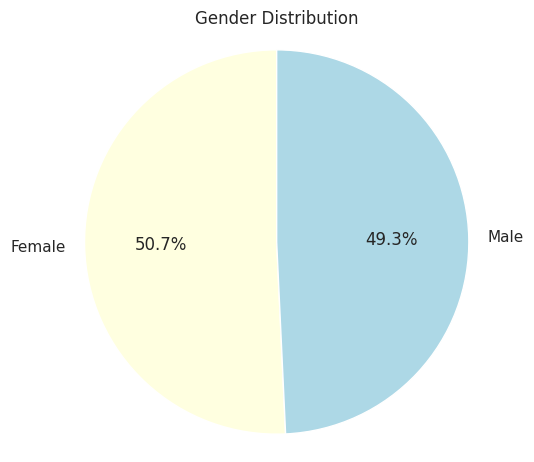

In [68]:
try:
    plt.figure(figsize=(12, 12))

    plt.subplot(2, 2, 1)
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['lightyellow', 'lightblue'])
    plt.title('Gender Distribution')
    plt.axis('equal')

except Exception as e:
    print(f"Error generating visualizations: {e}")

print("\nAnalysis complete.")

In [70]:
# Name length analysis
df['First Name Length'] = df['First Name'].str.len()
df['Last Name Length'] = df['Last Name'].str.len()
print("Name Length Statistics:")
print(f"Average first name length: {df['First Name Length'].mean():.1f} characters")
print(f"Average last name length: {df['Last Name Length'].mean():.1f} characters")

# First letter of name analysis
df['First Name Initial'] = df['First Name'].str[0]
first_initials = df['First Name Initial'].value_counts()
print("\nFirst Name Initial Distribution:")
print(first_initials)

# Gender ratio by job title
job_gender = pd.crosstab(df['Job Title'], df['Sex'])
print("\nGender Distribution by Job Title:")
print(job_gender)

Name Length Statistics:
Average first name length: 5.8 characters
Average last name length: 6.1 characters

First Name Initial Distribution:
First Name Initial
J    1000
C     969
M     903
A     785
S     767
D     715
K     673
B     625
T     560
R     528
L     454
G     357
E     343
P     289
H     217
N     206
V     132
W     131
F     126
I      90
Y      50
O      36
Z      28
X      16
Name: count, dtype: int64

Gender Distribution by Job Title:
Sex                               Female  Male
Job Title                                     
Academic librarian                     3    10
Accommodation manager                  8     4
Accountant, chartered                 10     5
Accountant, chartered certified        7    14
Accountant, chartered management       9    11
...                                  ...   ...
Water quality scientist                8    10
Web designer                           9     5
Wellsite geologist                    17    11
Writer                